In [1]:
import tensorflow as tf
import keras
import numpy as np
import sklearn

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("NumPy:", np.__version__)
print("Sklearn:", sklearn.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2026-05-23 14:11:06.348154: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779545466.372238    2152 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779545466.379831    2152 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779545466.398684    2152 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779545466.398708    2152 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779545466.398710    2152 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
Keras: 3.10.0
NumPy: 2.0.2
Sklearn: 1.6.1
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

In [3]:
df = pd.read_csv("/kaggle/input/datasets/inshrah11/media-pipe-asl-dataset/asl_landmarks_final.csv")

print("Shape:", df.shape)
print("\nSamples per class:")
print(df['label'].value_counts())

Shape: (2203, 64)

Samples per class:
label
J        128
Z        119
F         99
K         90
U         90
V         90
D         88
S         86
R         84
H         83
E         83
G         82
O         81
Y         81
W         80
L         78
T         75
B         71
I         70
P         70
Q         69
A         69
X         69
C         65
del       58
M         54
space     52
N         39
Name: count, dtype: int64


In [4]:
X = df.drop("label", axis=1).values.astype(np.float32)
y = df["label"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2203, 63)
y shape: (2203,)


In [5]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

labels_list = le.classes_.tolist()
num_classes = len(labels_list)

print("Number of classes:", num_classes)
print("Labels:", labels_list)

Number of classes: 28
Labels: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'space']


In [6]:
y_onehot = to_categorical(y_encoded)

print("y_onehot shape:", y_onehot.shape)

y_onehot shape: (2203, 28)


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # ← only ONE time, on raw X

print("X_scaled shape:", X_scaled.shape)
print("Sample scaled row:", X_scaled[0][:6])

X_scaled shape: (2203, 63)
Sample scaled row: [-1.2630615  -1.2447884  -0.8443066  -1.2053252  -1.4316006   0.41002494]


In [8]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print(" scaler.pkl saved")

 scaler.pkl saved


In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_onehot,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (1542, 63)
Val:   (330, 63)
Test:  (331, 63)


In [10]:
y_train_labels = np.argmax(y_train, axis=1)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = dict(enumerate(class_weights_array))

print("Class weights computed:")
for i, w in class_weights.items():
    print(f"  {labels_list[i]}: {w:.3f}")

Class weights computed:
  A: 1.147
  B: 1.101
  C: 1.197
  D: 0.888
  E: 0.950
  F: 0.798
  G: 0.966
  H: 0.950
  I: 1.124
  J: 0.612
  K: 0.874
  L: 1.001
  M: 1.449
  N: 2.040
  O: 0.966
  P: 1.124
  Q: 1.147
  R: 0.933
  S: 0.918
  T: 1.059
  U: 0.874
  V: 0.874
  W: 0.983
  X: 1.147
  Y: 0.966
  Z: 0.664
  del: 1.343
  space: 1.530


In [11]:
model = models.Sequential([
    layers.Input(shape=(63,)),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.1),

    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1779545476.737388    2152 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779545476.742599    2152 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 28)             │         1,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,652 (822.86 KB)

 Trainable params: 208,860 (815.86 KB)

 Non-trainable params: 1,792 (7.00 KB)

In [12]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


I0000 00:00:1779545480.033579    2224 service.cc:152] XLA service 0x7c8244005a00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779545480.033610    2224 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779545480.033614    2224 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779545480.473125    2224 cuda_dnn.cc:529] Loaded cuDNN version 91002


61/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0856 - loss: 3.6449

I0000 00:00:1779545483.497643    2224 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


97/97 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.1059 - loss: 3.4580 - val_accuracy: 0.3939 - val_loss: 2.6230
Epoch 2/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3544 - loss: 2.1077 - val_accuracy: 0.5909 - val_loss: 1.5552
Epoch 3/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5356 - loss: 1.4335 - val_accuracy: 0.8182 - val_loss: 0.8172
Epoch 4/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6428 - loss: 1.0782 - val_accuracy: 0.8515 - val_loss: 0.5269
Epoch 5/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7055 - loss: 0.9224 - val_accuracy: 0.8909 - val_loss: 0.3531
Epoch 6/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7566 - loss: 0.7285 - val_accuracy: 0.9000 - val_loss: 0.3335
Epoch 7/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7809 - loss: 0.6760 - val_accuracy: 0.9242 - val_loss: 0.2472
Epoch 8/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7891 - loss: 0.6221 - val_accuracy: 0.9152 - val_loss: 0

In [13]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)

print(f"\n Test Accuracy: {acc * 100:.2f}%")
print(f" Test Loss:     {loss:.4f}")


 Test Accuracy: 95.77%
 Test Loss:     0.1413


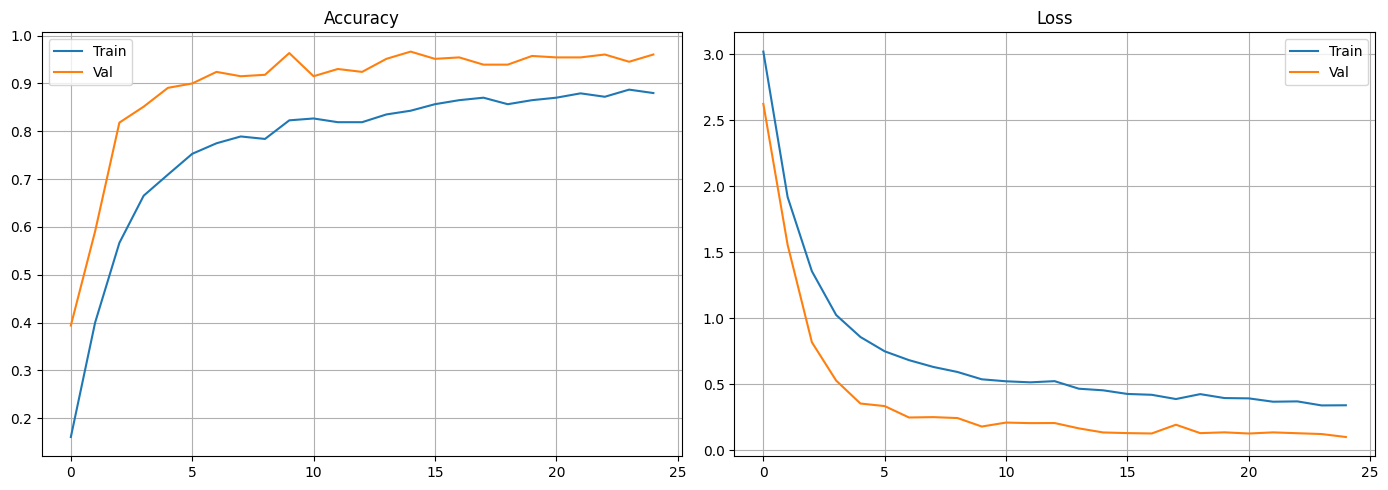

In [14]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_plot.png')
plt.show()

In [15]:
model.save("asl_model.h5")

print("asl_model.h5 saved")

asl_model.h5 saved


In [16]:
with open("labels.txt", "w") as f:
    for i, label in enumerate(labels_list):
        f.write(f"{i} {label}\n")

print(" labels.txt saved")
print("\nLabel order:")
for i, l in enumerate(labels_list):
    print(f"  {i}: {l}")

 labels.txt saved

Label order:
  0: A
  1: B
  2: C
  3: D
  4: E
  5: F
  6: G
  7: H
  8: I
  9: J
  10: K
  11: L
  12: M
  13: N
  14: O
  15: P
  16: Q
  17: R
  18: S
  19: T
  20: U
  21: V
  22: W
  23: X
  24: Y
  25: Z
  26: del
  27: space
